# 02 - EDA enfocado - Problema P1: Desempeño de entrega
### VERTEX INSIGHTS - Consultora de datos para Olist

## Resumen ejecutivo (lectura en 60 segundos)
*Cifras de la corrida sobre las 96.478 órdenes entregadas (dataset Olist, ~2017-2018).*

- **El dolor:** el **8.1%** de las entregas llega TARDE respecto a la promesa de Olist, y un **2.98%** adicional de órdenes ni siquiera se completa. Es real y medible.
- **Es tóxico:** una entrega tarde dispara la insatisfacción a **54%** (vs **9%** puntual → **5.9x**). El golpe ocurre justo al romperse la promesa, no por días absolutos.
- **Tiene tamaño:** el GMV (*Gross Merchandise Value* / valor bruto de mercancía) **expuesto** a la tardanza es del orden de **~R$1.1M**, consistente con el R$1.12M del embudo (ver Sección 4.3).
- **Es regional:** se concentra en el Norte/Nordeste (Alagoas **23.9%** tarde vs São Paulo **5.9%**, ~4x).
- **La palanca:** Olist pone un colchón mediano de **12 días** en su promesa; el dolor vive en la *cola* que se queda corta. **Afinar la estimación** (sobre todo a destinos remotos) es la acción de mayor retorno.


---

**Alcance de este notebook:** EDA (*Exploratory Data Analysis* / análisis exploratorio de datos) **enfocado a P1**. NO es modelado ni *feature engineering* (ingeniería de variables) - eso vive en notebooks posteriores. Aquí (1) caracterizamos y dimensionamos el dolor, (2) definimos el *target* (variable objetivo), (3) exploramos sus *drivers* (factores que lo mueven) y (4) entregamos un **mapa de leakage** y un **shortlist de features** como *handoff* a la siguiente fase.

## La variable objetivo (target)
`entrega_tarde = (fecha de entrega real > fecha estimada)` - tarde **respecto a la promesa** que ve el cliente, no respecto a días absolutos.

## Disciplina de *data leakage* (fuga de datos) - LEER ANTES DE TODO
*Data leakage* = usar, para predecir, información que en la vida real **todavía no existiría** en el momento de predecir. El modelo de P1 predeciría la tardanza **en el momento de la compra/aprobación** (lo llamamos **t0**), cuando el paquete aún no ha salido. Por tanto:

- **Insumos legítimos [t0]** (se conocen al comprar): fecha estimada, ubicación de comprador y vendedor, distancia, flete, peso/dimensiones del producto, categoría, momento de compra, y el **historial** del vendedor (su tasa pasada de despacho tardío).
- **Fuga [POST]** (solo se conoce DESPUÉS de la entrega): fecha de entrega real, días reales de tránsito, la propia reseña.
- **Matiz clave:** la fecha de entrega real **sí** se usa para *etiquetar* (construir el target en datos históricos) - eso es legítimo. Es **veneno como feature, no como etiqueta.**

A lo largo del notebook marcamos cada variable como **[t0]** (disponible al predecir) o **[POST]** (resultado / fuga).


## 1. Setup y carga de las 9 tablas

In [1]:
# === Setup ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (11, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
PALETA = {"tarde": "#E45756", "puntual": "#54A24B", "neutro": "#4C78A8", "acento": "#F58518"}

# Los 9 CSV viven en la MISMA carpeta que este notebook (ruta relativa = portable).
DATA_DIR = Path.cwd()
FIG_DIR  = Path.cwd() / "reports" / "figures" / "eda_p1"
FIG_DIR.mkdir(parents=True, exist_ok=True)
GUARDAR_FIGURAS = True

def savefig(nombre):
    if GUARDAR_FIGURAS:
        plt.savefig(FIG_DIR / f"{nombre}.png", dpi=120, bbox_inches="tight")

def haversine(lat1, lng1, lat2, lng2):
    """Distancia en km sobre la esfera terrestre entre dos puntos (lat/lng en grados)."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1); dlmb = np.radians(lng2 - lng1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

print("Setup listo. DATA_DIR =", DATA_DIR)
print("Figuras ->", FIG_DIR, "| guardar:", GUARDAR_FIGURAS)


Setup listo. DATA_DIR = c:\Users\juanc\OneDrive\Documentos\JUAN CARLOS\ESTUDIOS\CIENCIA DE DATOS\PROYECTO FINAL VERTEX INSIGHT\vertex-insights-olist-recommender\notebooks
Figuras -> c:\Users\juanc\OneDrive\Documentos\JUAN CARLOS\ESTUDIOS\CIENCIA DE DATOS\PROYECTO FINAL VERTEX INSIGHT\vertex-insights-olist-recommender\notebooks\reports\figures\eda_p1 | guardar: True


In [2]:
# === Carga de las 9 tablas ===
ARCHIVOS = {
    "customers":"olist_customers_dataset.csv", "geolocation":"olist_geolocation_dataset.csv",
    "items":"olist_order_items_dataset.csv",   "payments":"olist_order_payments_dataset.csv",
    "reviews":"olist_order_reviews_dataset.csv","orders":"olist_orders_dataset.csv",
    "products":"olist_products_dataset.csv",    "sellers":"olist_sellers_dataset.csv",
    "cat_trans":"product_category_name_translation.csv",
}
tablas = {}
for clave, archivo in ARCHIVOS.items():
    ruta = DATA_DIR / archivo
    if not ruta.exists():
        raise FileNotFoundError(f"No encuentro '{archivo}' en {DATA_DIR}. "
                                "Coloca los 9 CSV junto al notebook o ajusta DATA_DIR.")
    tablas[clave] = pd.read_csv(ruta)
    print(f"  {clave:12} {tablas[clave].shape[0]:>8,} filas x {tablas[clave].shape[1]:>2} columnas")

customers = tablas["customers"];   geo      = tablas["geolocation"]; items    = tablas["items"]
payments  = tablas["payments"];    reviews  = tablas["reviews"];     orders   = tablas["orders"]
products  = tablas["products"];    sellers  = tablas["sellers"];     cat_trans = tablas["cat_trans"]

# GMV por orden (suma de price de los items) -> usado en magnitud economica (Secciones 3 y 4.3)
order_value = items.groupby("order_id")["price"].sum()
print("\n9 tablas cargadas. GMV por orden precalculado.")


  customers      99,441 filas x  5 columnas
  geolocation  1,000,163 filas x  5 columnas
  items         112,650 filas x  7 columnas
  payments      103,886 filas x  5 columnas
  reviews        99,224 filas x  7 columnas
  orders         99,441 filas x  8 columnas
  products       32,951 filas x  9 columnas
  sellers         3,095 filas x  4 columnas
  cat_trans          71 filas x  2 columnas

9 tablas cargadas. GMV por orden precalculado.


## 2. Calidad de datos enfocada a P1

Miramos lo que decide la suerte de P1: el **ciclo temporal de la orden** (los *timestamps*) y la **granularidad** de las tablas que vamos a unir.

In [3]:
# === 2.1 Valores faltantes en el ciclo temporal ===
cols_tiempo = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
               "order_delivered_customer_date", "order_estimated_delivery_date"]
etiq = ["[t0] compra", "[t0] aprobacion", "[POST] despacho", "[POST] entrega", "[t0] PROMESA"]
print("Nulos en el ciclo temporal de 'orders':")
faltantes = {}
for c, et in zip(cols_tiempo, etiq):
    n = orders[c].isna().sum(); faltantes[c] = n
    print(f"  {c:32} {et:18} nulos: {n:>6,} ({n/len(orders)*100:5.2f}%)")
print("\nLos nulos NO son ruido: son ordenes que no se entregaron. order_status:")
print(orders["order_status"].value_counts().to_string())


Nulos en el ciclo temporal de 'orders':
  order_purchase_timestamp         [t0] compra        nulos:      0 ( 0.00%)
  order_approved_at                [t0] aprobacion    nulos:    160 ( 0.16%)
  order_delivered_carrier_date     [POST] despacho    nulos:  1,783 ( 1.79%)
  order_delivered_customer_date    [POST] entrega     nulos:  2,965 ( 2.98%)
  order_estimated_delivery_date    [t0] PROMESA       nulos:      0 ( 0.00%)

Los nulos NO son ruido: son ordenes que no se entregaron. order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


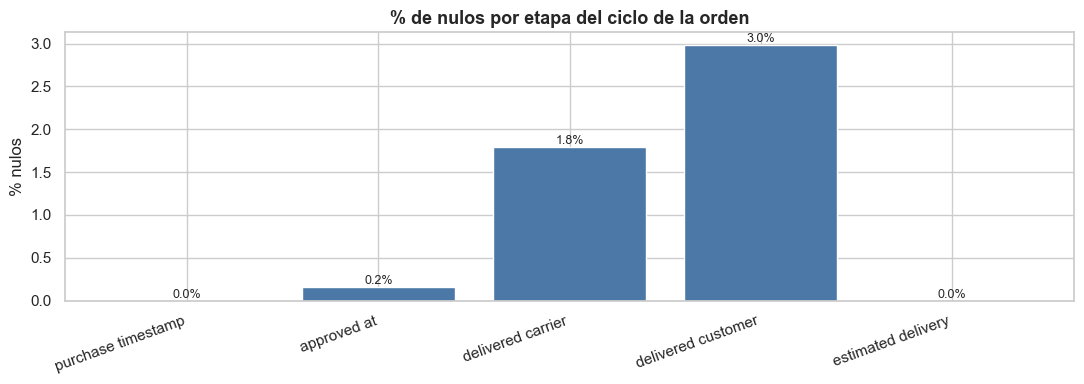

In [4]:
# Visual: nulos por etapa del ciclo (mas a la derecha del viaje = mas nulos = ordenes incompletas)
fig, ax = plt.subplots(figsize=(11, 4))
nombres = [c.replace("order_", "").replace("_date", "").replace("_", " ") for c in cols_tiempo]
vals = [faltantes[c]/len(orders)*100 for c in cols_tiempo]
ax.bar(nombres, vals, color=PALETA["neutro"])
ax.set_title("% de nulos por etapa del ciclo de la orden"); ax.set_ylabel("% nulos")
for i, vv in enumerate(vals): ax.text(i, vv, f"{vv:.1f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); savefig("02_nulos_ciclo"); plt.show()


In [5]:
# === 2.2 Granularidad, fan-out e integridad referencial ===
rev_por_orden  = reviews.groupby("order_id")["review_id"].nunique()
ord_por_review = reviews.groupby("review_id")["order_id"].nunique()
print("Granularidad de reviews:")
print(f"  order_id con 2+ resenas : {(rev_por_orden  >= 2).sum():,}")
print(f"  review_id en 2+ ordenes : {(ord_por_review >= 2).sum():,}  (casos raros)")
sellers_por_orden = items.groupby("order_id")["seller_id"].nunique()
print("\nVendedores por orden:")
print(f"  mono-vendedor (1)   : {(sellers_por_orden == 1).sum():,}  <- atribucion limpia")
print(f"  multi-vendedor (2+) : {(sellers_por_orden >= 2).sum():,}")
print("\nIntegridad referencial (0 huerfanos esperado):")
print(f"  items fuera de orders     : {(~items['order_id'].isin(orders['order_id'])).sum():,}")
print(f"  orders fuera de customers : {(~orders['customer_id'].isin(customers['customer_id'])).sum():,}")


Granularidad de reviews:
  order_id con 2+ resenas : 547
  review_id en 2+ ordenes : 789  (casos raros)

Vendedores por orden:
  mono-vendedor (1)   : 97,388  <- atribucion limpia
  multi-vendedor (2+) : 1,278

Integridad referencial (0 huerfanos esperado):
  items fuera de orders     : 0
  orders fuera de customers : 0


### 2.3 La base de análisis a nivel ORDEN

Decisiones de diseño (heredadas del embudo, ya auditadas): universo `delivered` (las únicas etiquetables tarde/puntual) · una orden = su reseña más reciente (neutraliza *fan-out*) · las no-entregadas se analizan aparte (Sección 3).

In [6]:
# === 2.3 Construccion de 'base' ===
orders_deliv = orders[orders["order_status"] == "delivered"].copy()
rev_unica = (reviews.sort_values("review_answer_timestamp")
             .drop_duplicates(subset="order_id", keep="last"))
base = orders_deliv.merge(
    rev_unica[["order_id","review_id","review_score","review_comment_message"]],
    on="order_id", how="left")
base = base.merge(customers[["customer_id","customer_state","customer_zip_code_prefix"]],
                  on="customer_id", how="left")
for c in cols_tiempo:
    base[c] = pd.to_datetime(base[c], errors="coerce")
print(f"Ordenes 'delivered'        : {len(orders_deliv):,}")
print(f"  con resena               : {base['review_score'].notna().sum():,}")
print(f"  sin fecha de entrega real: {base['order_delivered_customer_date'].isna().sum():,}  (se excluyen del calculo de 'tarde')")
print(f"\nbase: {base.shape[0]:,} filas x {base.shape[1]} columnas")


Ordenes 'delivered'        : 96,478
  con resena               : 95,832
  sin fecha de entrega real: 8  (se excluyen del calculo de 'tarde')

base: 96,478 filas x 13 columnas


## 3. Las órdenes que nunca llegaron (dolor de P1 puro, cuantificado)

Estas órdenes (canceladas, no disponibles…) son **el peor caso de P1**: una promesa rota del todo. No tienen fecha real, así que no entran al frame tarde/puntual - pero ahora **las cuantificamos** (cuánto GMV, qué peso, qué patrón).

> **Honestidad de medición:** hablamos de **GMV no realizado / asociado**, NO de "GMV perdido". Una cancelación puede ser del propio cliente o terminar en reembolso; no es pérdida pura.

In [7]:
# === 3. Caracterizacion + cuantificacion de las no-entregadas ===
status = orders["order_status"].value_counts()
print("Ordenes por estado (todas):")
for s, n in status.items():
    print(f"  {s:14} {n:>7,}  ({n/len(orders)*100:5.2f}%)")

no_entregadas = orders[orders["order_status"] != "delivered"].copy()
ne_ids = set(no_entregadas["order_id"])
gmv_ne    = order_value[order_value.index.isin(ne_ids)].sum()
gmv_total = order_value.sum()
print(f"\nTotal NO entregadas : {len(no_entregadas):,} ({len(no_entregadas)/len(orders)*100:.2f}%)")
print(f"GMV asociado (no realizado): R$ {gmv_ne:,.0f}  ({gmv_ne/gmv_total*100:.2f}% del GMV total)")

# Patron por ESTADO (que estados fallan mas en completarse)
tot_by_state = (orders.merge(customers[["customer_id","customer_state"]], on="customer_id", how="left")
                ["customer_state"].value_counts())
ne_by_state  = (no_entregadas.merge(customers[["customer_id","customer_state"]], on="customer_id", how="left")
                ["customer_state"].value_counts())
tasa_ne = (ne_by_state / tot_by_state * 100).dropna()
tasa_ne = tasa_ne[tot_by_state >= 500].sort_values(ascending=False)
print("\nEstados con mayor % de ordenes NO entregadas (vol >=500):")
print(tasa_ne.head(6).round(2).to_string())

# Patron por VENDEDOR (aprox: una orden cuenta por cada seller que la toca)
ne_sellers  = items[items["order_id"].isin(ne_ids)]["seller_id"].value_counts()
all_sellers = items["seller_id"].value_counts()
rate_seller = (ne_sellers / all_sellers * 100).dropna()
rate_seller = rate_seller[all_sellers >= 50].sort_values(ascending=False)
print("\nVendedores con mayor % de no entregadas (>=50 ordenes):")
print(rate_seller.head(5).round(2).to_string())

print("\nOPORTUNIDAD (fuera de alcance de este EDA): predecir la cancelacion seria OTRO target.")
print("Se anota como oportunidad; no se construye aqui (foco en P1 = entrega tardia).")


Ordenes por estado (todas):
  delivered       96,478  (97.02%)
  shipped          1,107  ( 1.11%)
  canceled           625  ( 0.63%)
  unavailable        609  ( 0.61%)
  invoiced           314  ( 0.32%)
  processing         301  ( 0.30%)
  created              5  ( 0.01%)
  approved             2  ( 0.00%)

Total NO entregadas : 2,963 (2.98%)
GMV asociado (no realizado): R$ 370,146  (2.72% del GMV total)

Estados con mayor % de ordenes NO entregadas (vol >=500):
customer_state
CE    4.27
MA    4.02
RJ    3.91
BA    3.67
PE    3.57
PB    3.54

Vendedores con mayor % de no entregadas (>=50 ordenes):
seller_id
dc8798cbf453b7e0f98745e396cc5616    15.69
18a349e75d307f4b4cc646a691ed4216    13.51
b18dc380845b24038cfc48006478f099    11.11
966cb4760537b1404caedd472cc610a5    10.67
b17b679f4f5ce2e03ce6968c62648246    10.53

OPORTUNIDAD (fuera de alcance de este EDA): predecir la cancelacion seria OTRO target.
Se anota como oportunidad; no se construye aqui (foco en P1 = entrega tardia).


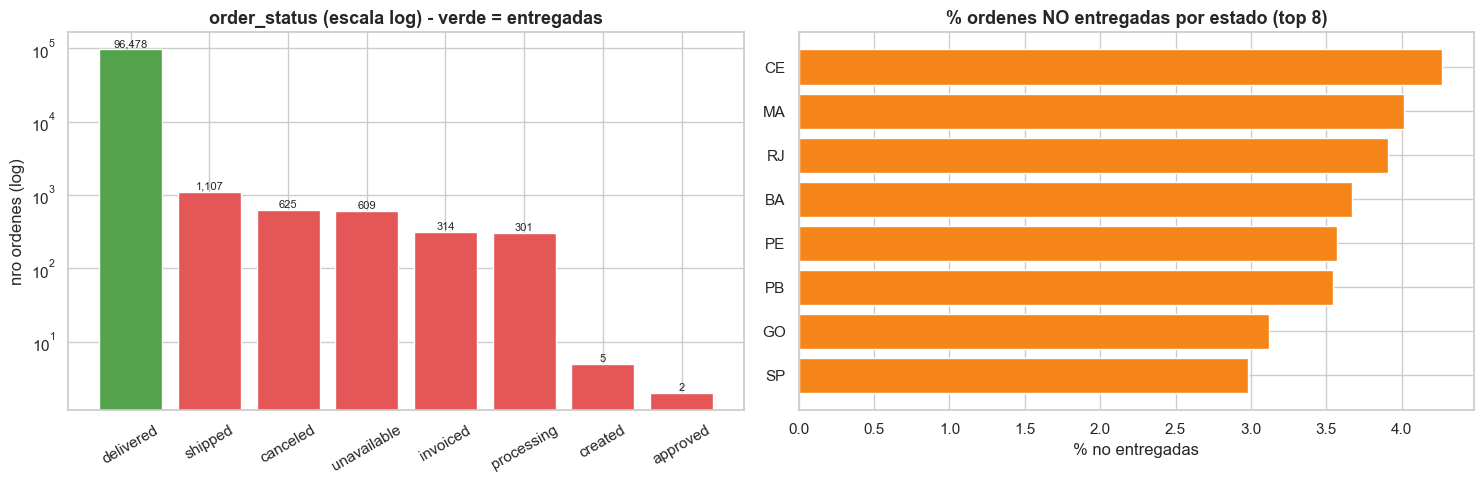

In [8]:
# Visual: estados de la orden + patron geografico de no-entregadas
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
colores = [PALETA["puntual"] if s == "delivered" else PALETA["tarde"] for s in status.index]
ax[0].bar(status.index, status.values, color=colores); ax[0].set_yscale("log")
ax[0].set_title("order_status (escala log) - verde = entregadas"); ax[0].set_ylabel("nro ordenes (log)")
ax[0].tick_params(axis="x", rotation=30)
for i, vv in enumerate(status.values): ax[0].text(i, vv, f"{vv:,}", ha="center", va="bottom", fontsize=8)
top_ne = tasa_ne.head(8).iloc[::-1]
ax[1].barh(top_ne.index, top_ne.values, color=PALETA["acento"])
ax[1].set_title("% ordenes NO entregadas por estado (top 8)"); ax[1].set_xlabel("% no entregadas")
plt.tight_layout(); savefig("03_no_entregadas"); plt.show()


## 4. El target: `entrega_tarde` y la magnitud del retraso

Se construye **contra la promesa**. Recordatorio: la fecha de entrega real es **[POST]** - aquí solo *etiqueta* el histórico, lo cual es legítimo.

In [9]:
# === 4.1 Construccion del target ===
d = base.dropna(subset=["order_delivered_customer_date","order_estimated_delivery_date"]).copy()
d["entrega_tarde"]   = d["order_delivered_customer_date"] > d["order_estimated_delivery_date"]
d["dias_vs_promesa"] = (d["order_delivered_customer_date"] - d["order_estimated_delivery_date"]).dt.days
tasa = d["entrega_tarde"].mean() * 100
print(f"Ordenes analizadas         : {len(d):,}")
print(f"Tasa base de entrega tarde : {tasa:.2f}%   (desbalance sano: minoria densa, modelable)")
print(f"dias_vs_promesa -> mediana {d['dias_vs_promesa'].median():.0f} | media {d['dias_vs_promesa'].mean():.1f} | "
      f"p10 {d['dias_vs_promesa'].quantile(.1):.0f} | p90 {d['dias_vs_promesa'].quantile(.9):.0f}")


Ordenes analizadas         : 96,470
Tasa base de entrega tarde : 8.11%   (desbalance sano: minoria densa, modelable)
dias_vs_promesa -> mediana -12 | media -11.9 | p10 -22 | p90 -2


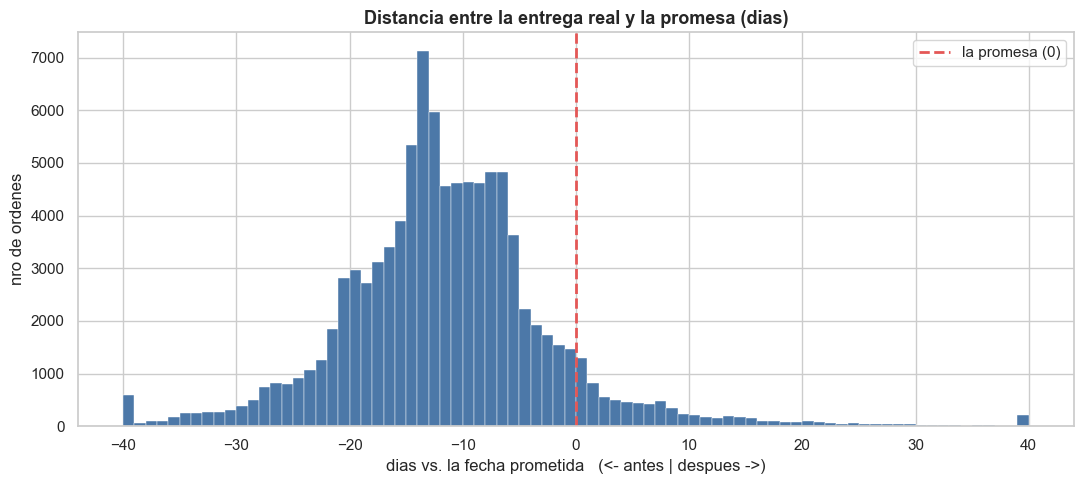

La masa esta a la IZQUIERDA del 0: Olist suele entregar ANTES de lo prometido (colchon).
La cola derecha del 0 es el dolor de P1.


In [10]:
# Visual: distancia entre entrega y promesa (0 = justo a tiempo)
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(d["dias_vs_promesa"].clip(-40, 40), bins=80, color=PALETA["neutro"], edgecolor="white", linewidth=0.3)
ax.axvline(0, color=PALETA["tarde"], linestyle="--", linewidth=2, label="la promesa (0)")
ax.set_title("Distancia entre la entrega real y la promesa (dias)")
ax.set_xlabel("dias vs. la fecha prometida   (<- antes | despues ->)"); ax.set_ylabel("nro de ordenes"); ax.legend()
plt.tight_layout(); savefig("04_dias_vs_promesa"); plt.show()
print("La masa esta a la IZQUIERDA del 0: Olist suele entregar ANTES de lo prometido (colchon).")
print("La cola derecha del 0 es el dolor de P1.")


### 4.2 Por qué importa: la huella de la tardanza en la satisfacción

In [11]:
# === 4.2 Tardanza vs satisfaccion ===
dr = d[d["review_score"].notna()].copy()
dr["review_score"] = dr["review_score"].astype(int)
dr["insatisfecho"] = dr["review_score"] <= 2
print("Distribucion de review_score:")
dist = dr["review_score"].value_counts().sort_index()
for s, n in dist.items():
    print(f"  {s} estrellas {n:>7,} ({n/len(dr)*100:5.2f}%)  {'#'*int(n/len(dr)*100/2)}")
ins_tarde = dr[dr["entrega_tarde"]]["insatisfecho"].mean()*100
ins_punt  = dr[~dr["entrega_tarde"]]["insatisfecho"].mean()*100
print(f"\nInsatisfaccion (<=2):  PUNTUAL {ins_punt:.2f}%  |  TARDE {ins_tarde:.2f}%  -> {ins_tarde/ins_punt:.1f}x mas")


Distribucion de review_score:
  1 estrellas   9,351 ( 9.76%)  ####
  2 estrellas   2,921 ( 3.05%)  #
  3 estrellas   7,916 ( 8.26%)  ####
  4 estrellas  18,888 (19.71%)  #########
  5 estrellas  56,748 (59.22%)  #############################

Insatisfaccion (<=2):  PUNTUAL 9.22%  |  TARDE 54.07%  -> 5.9x mas


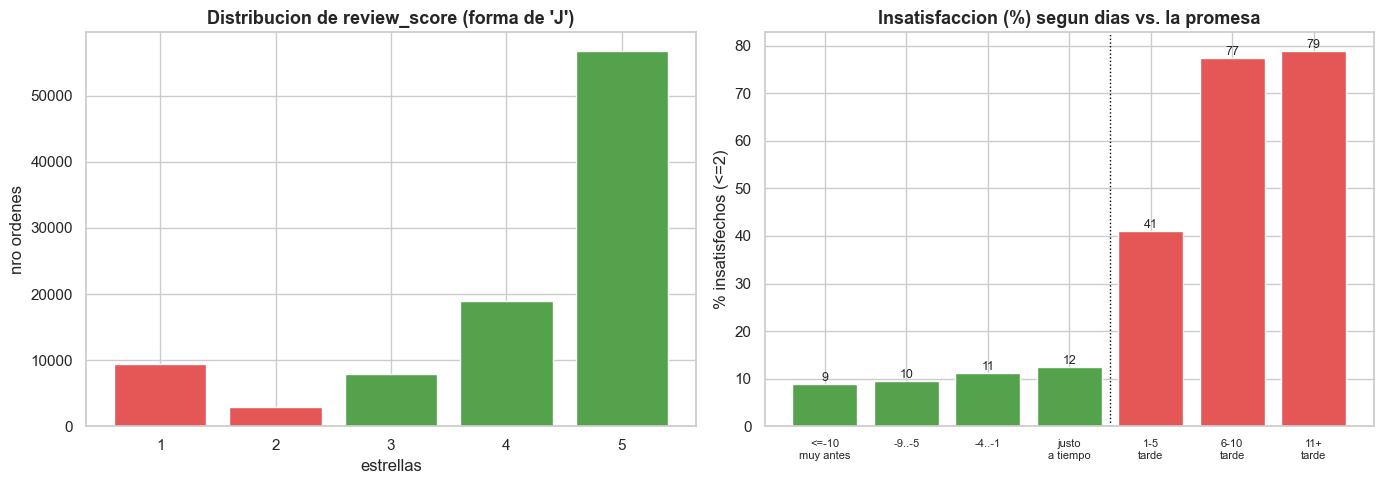

El salto ocurre al cruzar la promesa: el cliente reacciona a la EXPECTATIVA ROTA.


In [12]:
# Visual: la nota colapsa al cruzar la promesa
bins = [-1000, -10, -5, -1, 0, 5, 10, 1000]
labels = ["<=-10\nmuy antes","-9..-5","-4..-1","justo\na tiempo","1-5\ntarde","6-10\ntarde","11+\ntarde"]
dr["tramo"] = pd.cut(dr["dias_vs_promesa"], bins=bins, labels=labels)
grad = dr.groupby("tramo", observed=True)["insatisfecho"].mean()*100
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colores = [PALETA["tarde"] if s <= 2 else PALETA["puntual"] for s in dist.index]
ax[0].bar(dist.index, dist.values, color=colores)
ax[0].set_title("Distribucion de review_score (forma de 'J')"); ax[0].set_xlabel("estrellas"); ax[0].set_ylabel("nro ordenes")
cols = [PALETA["puntual"]]*4 + [PALETA["tarde"]]*3
ax[1].bar(range(len(grad)), grad.values, color=cols)
ax[1].set_xticks(range(len(grad))); ax[1].set_xticklabels(grad.index, fontsize=8)
ax[1].axvline(3.5, color="black", linestyle=":", linewidth=1)
ax[1].set_title("Insatisfaccion (%) segun dias vs. la promesa"); ax[1].set_ylabel("% insatisfechos (<=2)")
for i, vv in enumerate(grad.values): ax[1].text(i, vv, f"{vv:.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); savefig("04_target_satisfaccion"); plt.show()
print("El salto ocurre al cruzar la promesa: el cliente reacciona a la EXPECTATIVA ROTA.")


### 4.3 Magnitud económica del dolor (GMV expuesto)

Aterrizamos el dolor en reales (R$). **GMV expuesto**, no "perdido": la venta ya ocurrió; el riesgo es churn y reputación a futuro.

In [13]:
# === 4.3 GMV expuesto ===
dv = d.copy()
dv["gmv"] = dv["order_id"].map(order_value)
gmv_base  = dv["gmv"].sum()
gmv_tarde = dv.loc[dv["entrega_tarde"], "gmv"].sum()
n_tarde   = int(dv["entrega_tarde"].sum())
aov_tarde = dv.loc[dv["entrega_tarde"], "gmv"].mean()
aov_punt  = dv.loc[~dv["entrega_tarde"], "gmv"].mean()
print(f"GMV base (entregadas)   : R$ {gmv_base:,.0f}  sobre {len(dv):,} ordenes")
print(f"GMV EXPUESTO a tardanza : R$ {gmv_tarde:,.0f}  ({gmv_tarde/gmv_base*100:.1f}% del GMV) en {n_tarde:,} ordenes")
print(f"AOV (valor medio de orden): tarde R$ {aov_tarde:.0f}  vs  puntual R$ {aov_punt:.0f}")
print(f"\n+ GMV no realizado (no entregadas, Seccion 3) : R$ {gmv_ne:,.0f}")
print(f"= dolor de entrega total (expuesto + no realizado): R$ {gmv_tarde + gmv_ne:,.0f}")
print("\nReconciliacion con el embudo (Report 7.2): reporto ~R$1.12M de GMV-tarde sobre las 95.832")
print("con resena; aqui sale sobre las 96.470 entregadas -> de ahi la pequena diferencia. Mismo")
print("orden de magnitud = consistente.")


GMV base (entregadas)   : R$ 13,220,249  sobre 96,470 ordenes
GMV EXPUESTO a tardanza : R$ 1,158,921  (8.8% del GMV) en 7,826 ordenes
AOV (valor medio de orden): tarde R$ 148  vs  puntual R$ 136

+ GMV no realizado (no entregadas, Seccion 3) : R$ 370,146
= dolor de entrega total (expuesto + no realizado): R$ 1,529,066

Reconciliacion con el embudo (Report 7.2): reporto ~R$1.12M de GMV-tarde sobre las 95.832
con resena; aqui sale sobre las 96.470 entregadas -> de ahi la pequena diferencia. Mismo
orden de magnitud = consistente.


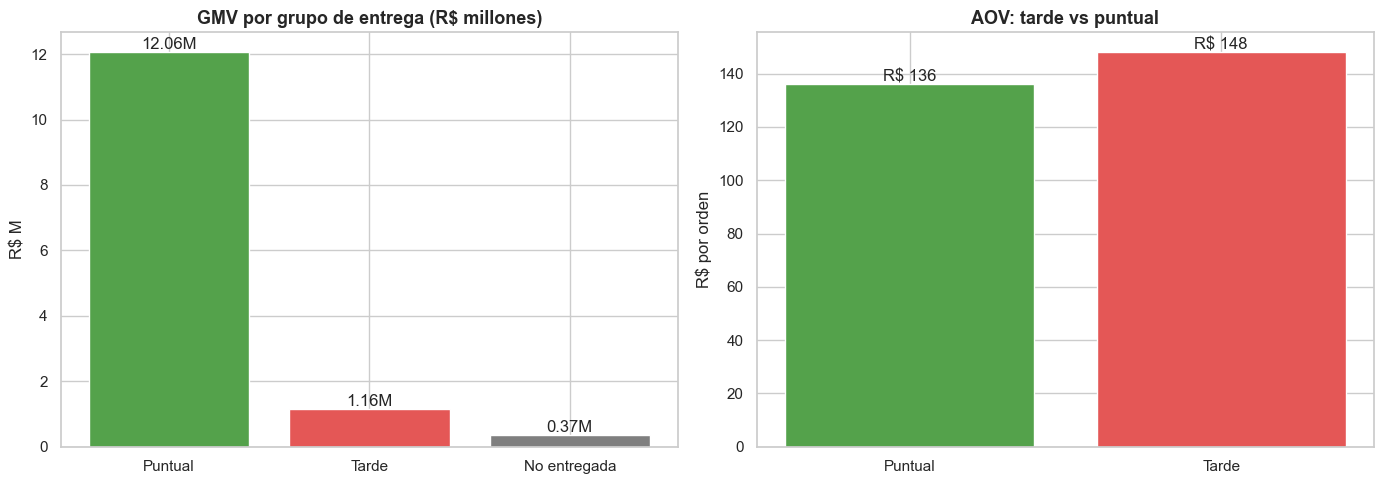

In [14]:
# Visual: GMV por grupo y AOV
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
vals = [gmv_base - gmv_tarde, gmv_tarde, gmv_ne]
ax[0].bar(["Puntual","Tarde","No entregada"], [v/1e6 for v in vals],
          color=[PALETA["puntual"], PALETA["tarde"], "#7f7f7f"])
ax[0].set_title("GMV por grupo de entrega (R$ millones)"); ax[0].set_ylabel("R$ M")
for i, v in enumerate(vals): ax[0].text(i, v/1e6, f"{v/1e6:.2f}M", ha="center", va="bottom")
ax[1].bar(["Puntual","Tarde"], [aov_punt, aov_tarde], color=[PALETA["puntual"], PALETA["tarde"]])
ax[1].set_title("AOV: tarde vs puntual"); ax[1].set_ylabel("R$ por orden")
for i, v in enumerate([aov_punt, aov_tarde]): ax[1].text(i, v, f"R$ {v:.0f}", ha="center", va="bottom")
plt.tight_layout(); savefig("04_gmv"); plt.show()


## 5. El error de la propia estimación de Olist (la PALANCA de P1)

La palanca no es "entregar más rápido" (Olist no maneja al transportador) sino **afinar la promesa**. `colchon = dias_prometidos - dias_reales`: >0 sobró colchón, <0 la promesa se quedó corta (= tarde).

In [15]:
# === 5. Error de estimacion ===
e = d.copy()
e["dias_reales"]     = (e["order_delivered_customer_date"] - e["order_purchase_timestamp"]).dt.days
e["dias_prometidos"] = (e["order_estimated_delivery_date"] - e["order_purchase_timestamp"]).dt.days
e["colchon"]         = e["dias_prometidos"] - e["dias_reales"]
print(f"Dias reales de entrega   -> mediana {e['dias_reales'].median():.0f} | media {e['dias_reales'].mean():.1f}")
print(f"Dias prometidos          -> mediana {e['dias_prometidos'].median():.0f} | media {e['dias_prometidos'].mean():.1f}")
print(f"Colchon (prometido-real) -> mediana {e['colchon'].median():.0f} | media {e['colchon'].mean():.1f}")
print(f"\n% de ordenes donde la promesa se quedo CORTA (colchon<0 = tarde): {(e['colchon']<0).mean()*100:.2f}%")
print("\nOlist mete un colchon GRANDE en mediana, pero se queda corto en una cola de envios.")
print("Afinar = recortar colchon donde sobra y ampliarlo donde falta. Esa es la palanca de P1.")


Dias reales de entrega   -> mediana 10 | media 12.1
Dias prometidos          -> mediana 23 | media 23.4
Colchon (prometido-real) -> mediana 12 | media 11.3

% de ordenes donde la promesa se quedo CORTA (colchon<0 = tarde): 7.57%

Olist mete un colchon GRANDE en mediana, pero se queda corto en una cola de envios.
Afinar = recortar colchon donde sobra y ampliarlo donde falta. Esa es la palanca de P1.


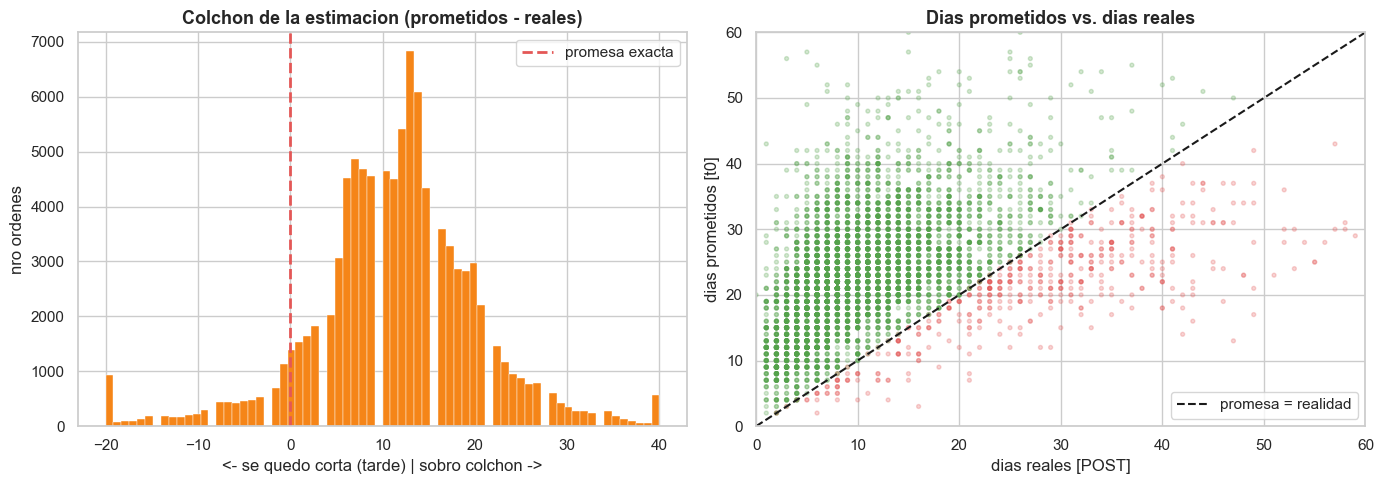

Puntos por DEBAJO de la linea = la promesa se quedo corta (rojos = tarde).


In [16]:
# Visual: promesa vs realidad
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(e["colchon"].clip(-20, 40), bins=70, color=PALETA["acento"], edgecolor="white", linewidth=0.3)
ax[0].axvline(0, color=PALETA["tarde"], linestyle="--", linewidth=2, label="promesa exacta")
ax[0].set_title("Colchon de la estimacion (prometidos - reales)")
ax[0].set_xlabel("<- se quedo corta (tarde) | sobro colchon ->"); ax[0].set_ylabel("nro ordenes"); ax[0].legend()
m = e.sample(min(6000, len(e)), random_state=42)
ax[1].scatter(m["dias_reales"], m["dias_prometidos"], s=8, alpha=0.25,
              c=m["entrega_tarde"].map({True: PALETA["tarde"], False: PALETA["puntual"]}))
ax[1].plot([0,60],[0,60], "k--", linewidth=1.5, label="promesa = realidad")
ax[1].set_xlim(0,60); ax[1].set_ylim(0,60)
ax[1].set_title("Dias prometidos vs. dias reales")
ax[1].set_xlabel("dias reales [POST]"); ax[1].set_ylabel("dias prometidos [t0]"); ax[1].legend()
plt.tight_layout(); savefig("05_colchon_estimacion"); plt.show()
print("Puntos por DEBAJO de la linea = la promesa se quedo corta (rojos = tarde).")


## 6. Drivers conocidos en t0 (candidatos a *feature*)

Para cada driver miramos su relación con la tardanza **y** anotamos si es **[t0]** (usable) o **[POST]** (fuga). Solo los **[t0]** pueden ser features.

### 6.1 El vendedor: ¿despacha a tiempo?  *(frontera P1↔P3 → feature [t0])*

In [17]:
# === 6.1 Vendedor (mono-vendedor para atribucion limpia) ===
mono = sellers_por_orden[sellers_por_orden == 1].index
seller_orden = (items[items["order_id"].isin(mono)]
                .drop_duplicates("order_id")[["order_id","seller_id","shipping_limit_date"]])
v = d.merge(seller_orden, on="order_id", how="inner")
v["shipping_limit_date"] = pd.to_datetime(v["shipping_limit_date"], errors="coerce")
v["despacho_tarde"] = v["order_delivered_carrier_date"] > v["shipping_limit_date"]
v["insatisfecho"]   = v["review_score"] <= 2
print(f"Ordenes mono-vendedor : {len(v):,} | vendedores: {v['seller_id'].nunique():,}")
print(f"Tasa global de despacho tardio: {v['despacho_tarde'].mean()*100:.2f}%")
UMBRAL = 30
opv = v.groupby("seller_id").size(); val = opv[opv >= UMBRAL].index
g = (v[v["seller_id"].isin(val)].groupby("seller_id")
       .agg(n=("entrega_tarde","size"), tasa_tarde=("entrega_tarde","mean"),
            tasa_despacho_tarde=("despacho_tarde","mean")))
print(f"\nVendedores con >={UMBRAL} ordenes: {len(val):,} (cubren {v['seller_id'].isin(val).mean()*100:.0f}%)")
print("Dispersion de la tasa de ENTREGA TARDE entre vendedores:")
for p in [10,25,50,75,90]:
    print(f"  p{p:<2}: {g['tasa_tarde'].quantile(p/100)*100:5.2f}%")


Ordenes mono-vendedor : 95,195 | vendedores: 2,948
Tasa global de despacho tardio: 9.10%

Vendedores con >=30 ordenes: 615 (cubren 83%)
Dispersion de la tasa de ENTREGA TARDE entre vendedores:
  p10:  2.22%
  p25:  3.76%
  p50:  6.76%
  p75: 10.82%
  p90: 15.00%


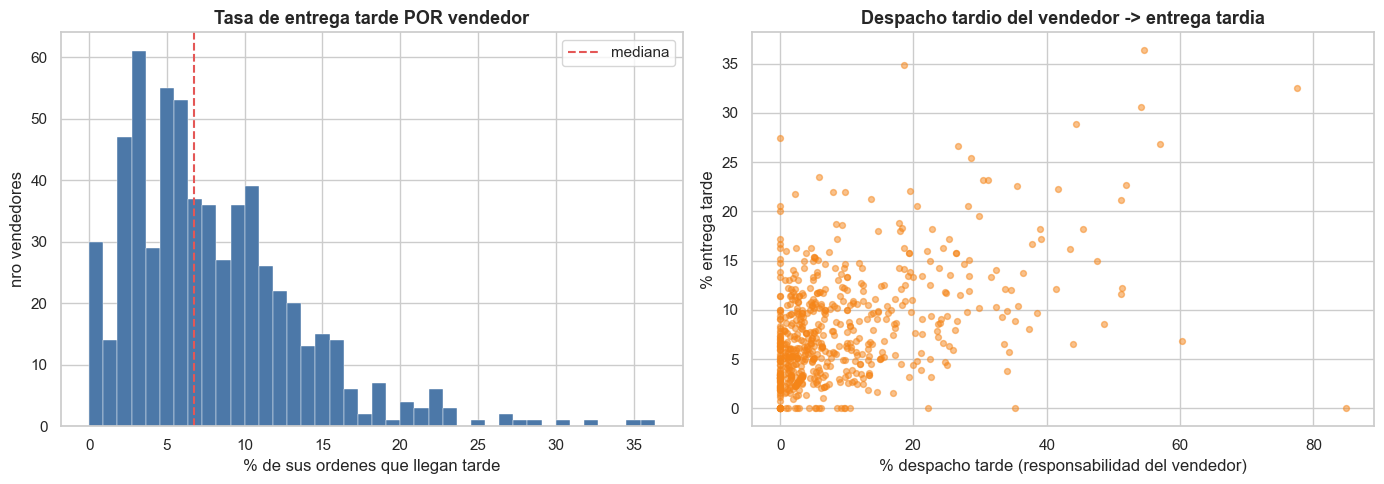

El historial del vendedor es senal util y LEGITIMA [t0] (se calcula con ordenes pasadas).


In [18]:
# Visual: el vendedor mueve la tardanza
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(g["tasa_tarde"]*100, bins=40, color=PALETA["neutro"], edgecolor="white", linewidth=0.3)
ax[0].axvline(g["tasa_tarde"].median()*100, color=PALETA["tarde"], linestyle="--", label="mediana")
ax[0].set_title("Tasa de entrega tarde POR vendedor")
ax[0].set_xlabel("% de sus ordenes que llegan tarde"); ax[0].set_ylabel("nro vendedores"); ax[0].legend()
ax[1].scatter(g["tasa_despacho_tarde"]*100, g["tasa_tarde"]*100, s=18, alpha=0.5, color=PALETA["acento"])
ax[1].set_title("Despacho tardio del vendedor -> entrega tardia")
ax[1].set_xlabel("% despacho tarde (responsabilidad del vendedor)"); ax[1].set_ylabel("% entrega tarde")
plt.tight_layout(); savefig("06_vendedor"); plt.show()
print("El historial del vendedor es senal util y LEGITIMA [t0] (se calcula con ordenes pasadas).")


### 6.1-bis Sensibilidad de la VENTANA del historial del vendedor

Antes de hacer *feature engineering* hay que decidir **qué ventana** usar para la tasa histórica del vendedor: toda su historia (*expanding*) o las últimas N órdenes. Trade-off: ventana corta = más reactiva pero ruidosa y exige menos historia; larga = estable. Aquí medimos ese trade-off de forma **leak-aware** (solo órdenes anteriores).

In [19]:
# === 6.1-bis Sensibilidad de la ventana ===
w = v.sort_values("order_purchase_timestamp").reset_index(drop=True).copy()
w["t"] = w["entrega_tarde"].astype(int)

# Expanding (toda la historia PREVIA), vectorizado
gc = w.groupby("seller_id")["t"]
w["n_prev"]   = gc.cumcount()
w["hist_exp"] = (gc.cumsum() - w["t"]) / w["n_prev"].replace(0, np.nan)

# Ventanas rodantes: ultimas N PREVIAS
for N in [5, 10, 20]:
    w[f"hist_{N}"] = (w.groupby("seller_id")["t"]
                        .apply(lambda s: s.shift().rolling(N, min_periods=N).mean())
                        .reset_index(level=0, drop=True))

def evalua(col):
    """Devuelve (separacion en pts, cobertura en %). Separacion = tasa real de tardanza
    en el tercil ALTO del historico menos el tercil BAJO (mas alto = mas predictivo)."""
    sub = w[[col, "t"]].dropna()
    if len(sub) < 100: return np.nan, np.nan
    q1, q3 = sub[col].quantile([1/3, 2/3])
    bajo = sub[sub[col] <= q1]["t"].mean(); alto = sub[sub[col] >= q3]["t"].mean()
    return (alto - bajo) * 100, len(sub)/len(w)*100

opciones = {"toda (expanding)":"hist_exp", "ultimas 5":"hist_5", "ultimas 10":"hist_10", "ultimas 20":"hist_20"}
res = pd.DataFrame({nom: dict(zip(["separacion_pts","cobertura_pct"],
                   [round(x,2) for x in evalua(col)])) for nom, col in opciones.items()}).T
print("Sensibilidad de la ventana del historial del vendedor:")
print(res.to_string())
print("\nMas separacion = el historico predice mejor el resultado; mas cobertura = exige menos historia.")


Sensibilidad de la ventana del historial del vendedor:
                  separacion_pts  cobertura_pct
toda (expanding)            6.34          96.90
ultimas 5                   2.71          88.33
ultimas 10                  7.43          80.97
ultimas 20                  9.29          71.01

Mas separacion = el historico predice mejor el resultado; mas cobertura = exige menos historia.


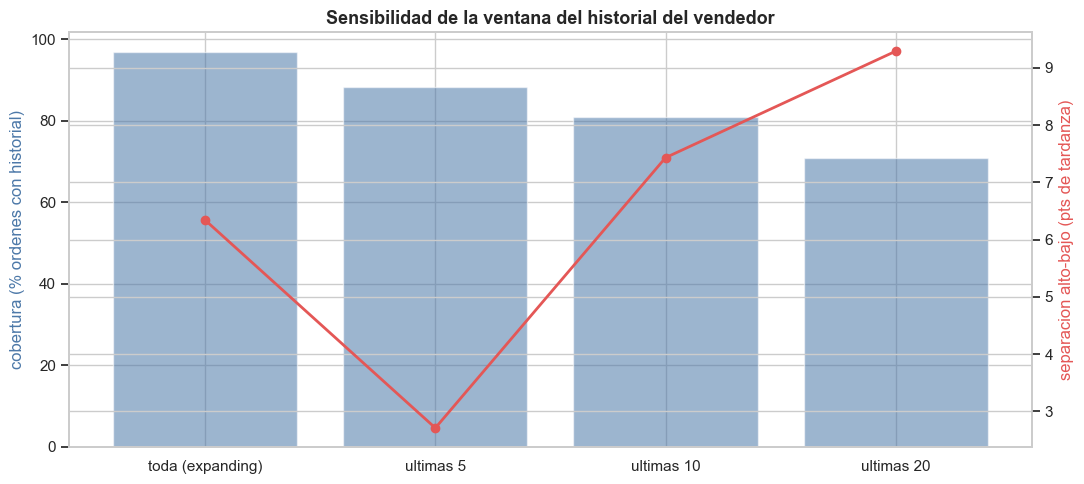

Recomendacion (a confirmar con estos numeros): 'expanding' con un minimo de ordenes
previas conserva la mayor cobertura sin perder separacion; las ventanas cortas exigen
mas historia (menos cobertura) a cambio de poca ganancia. Definir el minimo en FE.


In [20]:
# Visual: cobertura (barras) vs separacion (linea) por ventana
fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(res))
ax1.bar(x, res["cobertura_pct"], color=PALETA["neutro"], alpha=0.55)
ax1.set_ylabel("cobertura (% ordenes con historial)", color=PALETA["neutro"])
ax1.set_xticks(list(x)); ax1.set_xticklabels(res.index)
ax2 = ax1.twinx()
ax2.plot(x, res["separacion_pts"], color=PALETA["tarde"], marker="o", linewidth=2)
ax2.set_ylabel("separacion alto-bajo (pts de tardanza)", color=PALETA["tarde"])
ax1.set_title("Sensibilidad de la ventana del historial del vendedor")
plt.tight_layout(); savefig("06_ventana_vendedor"); plt.show()
print("Recomendacion (a confirmar con estos numeros): 'expanding' con un minimo de ordenes")
print("previas conserva la mayor cobertura sin perder separacion; las ventanas cortas exigen")
print("mas historia (menos cobertura) a cambio de poca ganancia. Definir el minimo en FE.")


### 6.2 El flete  *(feature [t0])*

In [21]:
# === 6.2 Flete / ratio flete-valor ===
agg = items.groupby("order_id").agg(flete_total=("freight_value","sum"), precio_total=("price","sum")).reset_index()
f = d.merge(agg, on="order_id", how="inner")
f = f[f["precio_total"] > 0].copy()
f["ratio_flete"] = f["flete_total"] / f["precio_total"]
f["tramo_flete"] = pd.qcut(f["ratio_flete"], 5, labels=["Q1 bajo","Q2","Q3","Q4","Q5 alto"], duplicates="drop")
tf = f.groupby("tramo_flete", observed=True).agg(ordenes=("entrega_tarde","size"),
        tarde_pct=("entrega_tarde", lambda x: round(x.mean()*100,2)))
print("Tasa de entrega tarde por tramo de flete/valor:"); print(tf.to_string())
print("\nConfirmado del embudo: el flete alto NO predice mas tardanza (la estimacion ya absorbe la")
print("distancia). Driver DEBIL para P1, pero la variable se conoce en t0.")


Tasa de entrega tarde por tramo de flete/valor:
             ordenes  tarde_pct
tramo_flete                    
Q1 bajo        19294       8.27
Q2             19294       7.93
Q3             19301       7.60
Q4             19296       8.40
Q5 alto        19285       8.37

Confirmado del embudo: el flete alto NO predice mas tardanza (la estimacion ya absorbe la
distancia). Driver DEBIL para P1, pero la variable se conoce en t0.


### 6.3 El producto: peso, volumen y categoría  *(features [t0])*

In [22]:
# === 6.3 Producto ===
it_prod = (items.drop_duplicates("order_id")[["order_id","product_id"]]
           .merge(products[["product_id","product_category_name","product_weight_g",
                            "product_length_cm","product_height_cm","product_width_cm"]], on="product_id", how="left")
           .merge(cat_trans, on="product_category_name", how="left"))
it_prod["volumen_cm3"] = it_prod["product_length_cm"]*it_prod["product_height_cm"]*it_prod["product_width_cm"]
p = d.merge(it_prod, on="order_id", how="left")
p_ok = p.dropna(subset=["product_weight_g"]).copy()
p_ok["tramo_peso"] = pd.qcut(p_ok["product_weight_g"], 5,
                             labels=["muy ligero","ligero","medio","pesado","muy pesado"], duplicates="drop")
tp = p_ok.groupby("tramo_peso", observed=True)["entrega_tarde"].mean()*100
print("Tasa de entrega tarde por peso del producto:"); print(tp.round(2).to_string())
cat = (p.dropna(subset=["product_category_name_english"]).groupby("product_category_name_english")
       .agg(n=("entrega_tarde","size"), tarde=("entrega_tarde","mean")))
cat = cat[cat["n"] >= 300].sort_values("tarde", ascending=False)
print("\nTop 8 categorias con MAS tardanza (>=300 ordenes):")
print(cat.head(8).assign(tarde=lambda x:(x["tarde"]*100).round(2)).to_string())


Tasa de entrega tarde por peso del producto:
tramo_peso
muy ligero    7.32
ligero        8.37
medio         7.67
pesado        8.43
muy pesado    8.96

Top 8 categorias con MAS tardanza (>=300 ordenes):
                                    n  tarde
product_category_name_english               
audio                             344  13.08
home_confort                      370  10.27
food                              435  10.11
electronics                      2507   9.85
baby                             2763   9.34
office_furniture                 1246   9.23
construction_tools_construction   728   9.20
health_beauty                    8608   8.99


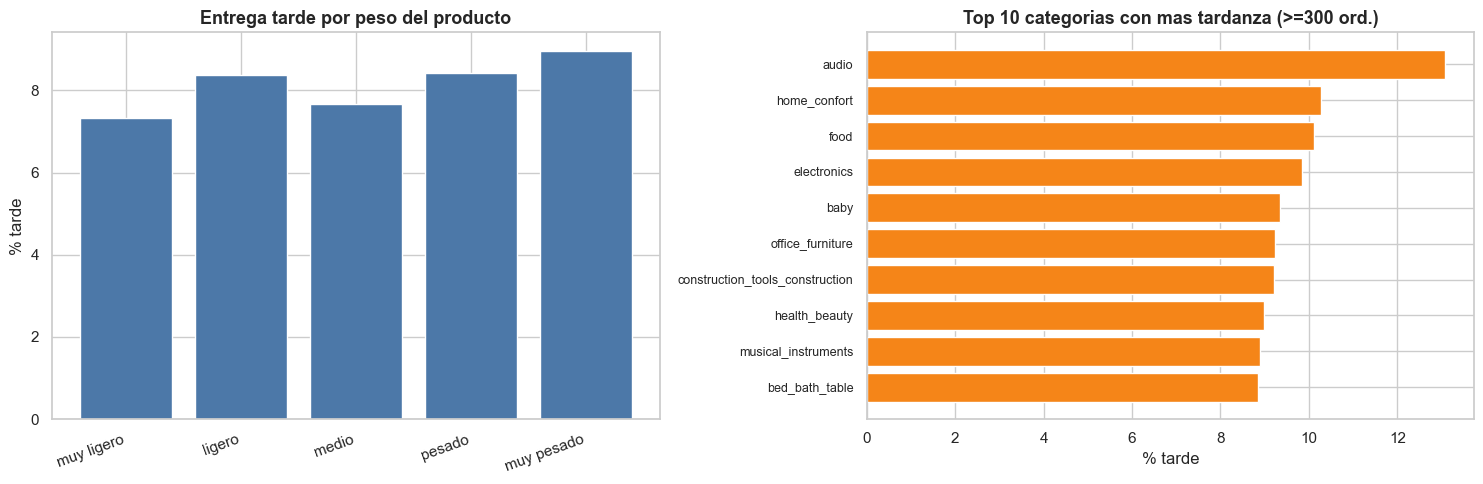

In [23]:
# Visual: peso y categoria
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(len(tp)), tp.values, color=PALETA["neutro"])
ax[0].set_xticks(range(len(tp))); ax[0].set_xticklabels(tp.index, rotation=20, ha="right")
ax[0].set_title("Entrega tarde por peso del producto"); ax[0].set_ylabel("% tarde")
top = cat.head(10)
ax[1].barh(range(len(top)), top["tarde"].values*100, color=PALETA["acento"])
ax[1].set_yticks(range(len(top))); ax[1].set_yticklabels(top.index, fontsize=9); ax[1].invert_yaxis()
ax[1].set_title("Top 10 categorias con mas tardanza (>=300 ord.)"); ax[1].set_xlabel("% tarde")
plt.tight_layout(); savefig("06_producto"); plt.show()


### 6.4 Estacionalidad: ¿cuándo se compra?  *(feature [t0])*

**Corrección sobre la v1:** sin filtrar, los meses con muy pocas órdenes (inicios de 2016) daban tasas de 0% o 100% - un artefacto, no un hallazgo. Filtramos a meses con volumen suficiente para ver la señal real.

In [24]:
# === 6.4 Temporal (con filtro de volumen) ===
t = d.copy()
t["mes"] = t["order_purchase_timestamp"].dt.to_period("M").astype(str)
t["dow"] = t["order_purchase_timestamp"].dt.dayofweek
vol_mes = t["mes"].value_counts()
MIN_MES = 200
meses_validos = vol_mes[vol_mes >= MIN_MES].index
tv = t[t["mes"].isin(meses_validos)]
mens = (tv.groupby("mes")["entrega_tarde"].mean()*100).sort_index()
dow  = t.groupby("dow")["entrega_tarde"].mean()*100
print(f"Rango temporal bruto: {t['order_purchase_timestamp'].min().date()} -> {t['order_purchase_timestamp'].max().date()}")
descartados = sorted(set(vol_mes.index) - set(meses_validos))
print(f"Meses descartados por bajo volumen (<{MIN_MES} ord.): {descartados}")
print(f"Tasa de tardanza por mes (validos) -> min {mens.min():.1f}% / max {mens.max():.1f}% (pico REAL en {mens.idxmax()})")
print("El pico real es un mes con volumen, no 1 orden. Candidatos a investigar en FE: efecto de")
print("fin de ano y un posible incidente logistico puntual; no afirmamos la causa sin mas evidencia.")


Rango temporal bruto: 2016-09-15 -> 2018-08-29
Meses descartados por bajo volumen (<200 ord.): ['2016-09', '2016-12']
Tasa de tardanza por mes (validos) -> min 1.1% / max 21.4% (pico REAL en 2018-03)
El pico real es un mes con volumen, no 1 orden. Candidatos a investigar en FE: efecto de
fin de ano y un posible incidente logistico puntual; no afirmamos la causa sin mas evidencia.


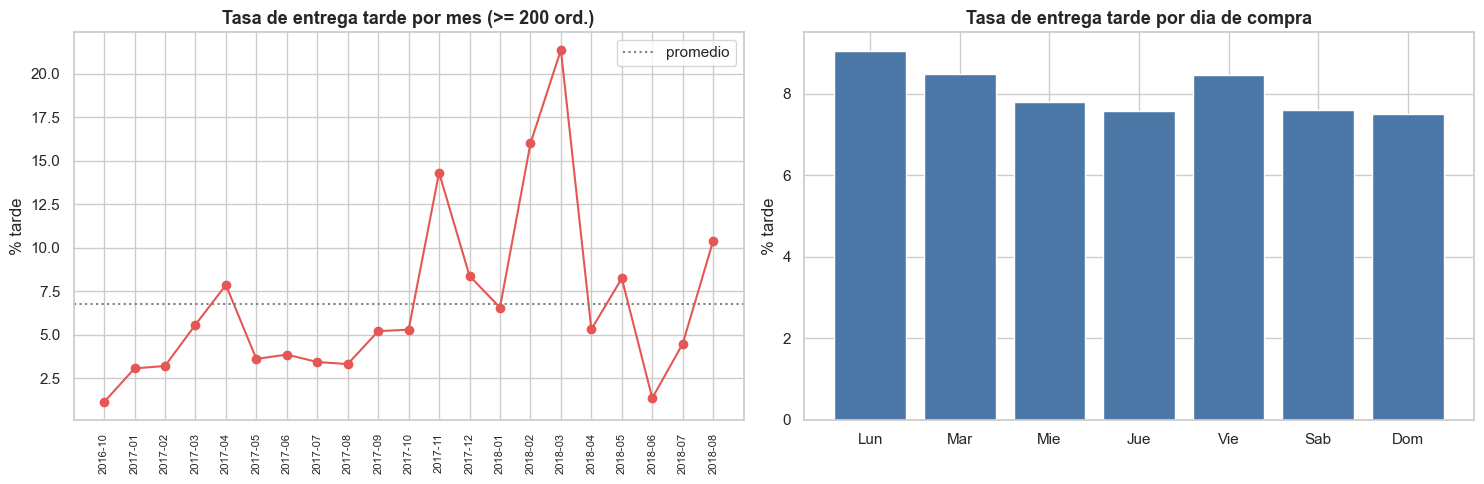

In [25]:
# Visual: estacionalidad (meses validos) + dia de semana
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(range(len(mens)), mens.values, marker="o", color=PALETA["tarde"])
ax[0].set_xticks(range(len(mens))); ax[0].set_xticklabels(mens.index, rotation=90, fontsize=8)
ax[0].set_title(f"Tasa de entrega tarde por mes (>= {MIN_MES} ord.)"); ax[0].set_ylabel("% tarde")
ax[0].axhline(mens.mean(), color="gray", linestyle=":", label="promedio")
ax[0].legend()
dias = ["Lun","Mar","Mie","Jue","Vie","Sab","Dom"]
ax[1].bar(dias, dow.values, color=PALETA["neutro"])
ax[1].set_title("Tasa de entrega tarde por dia de compra"); ax[1].set_ylabel("% tarde")
plt.tight_layout(); savefig("06_temporal"); plt.show()


## 7. Geoespacial a fondo: el reencuadre regional de P1

El hallazgo más vendible: la tardanza se concentra en el **Norte/Nordeste**. Aquí va la lección geoespacial del proyecto.

In [26]:
# === 7.1 Dolor de entrega por ESTADO del comprador ===
gestado = d.copy(); gestado["insatisfecho"] = gestado["review_score"] <= 2
ga = gestado.groupby("customer_state").agg(
    ordenes=("entrega_tarde","size"),
    tarde_pct=("entrega_tarde", lambda x: round(x.mean()*100,2)),
    insat_pct=("insatisfecho", lambda x: round(x.mean()*100,2)))
ga = ga[ga["ordenes"] >= 200].sort_values("tarde_pct", ascending=False)
print("PEORES 6 (mas tardanza):"); print(ga.head(6).to_string())
print("\nMEJORES 6 (menos tardanza):"); print(ga.tail(6).to_string())


PEORES 6 (mas tardanza):
                ordenes  tarde_pct  insat_pct
customer_state                               
AL                  397      23.93      21.16
MA                  717      19.67      19.80
PI                  476      15.97      15.97
CE                 1279      15.32      17.04
SE                  335      15.22      18.81
BA                 3256      14.04      16.86

MEJORES 6 (menos tardanza):
                ordenes  tarde_pct  insat_pct
customer_state                               
DF                 2080       7.07      13.17
MT                  886       6.77      12.64
SP                40494       5.89      10.63
MG                11354       5.61      11.68
PR                 4923       5.00      10.83
RO                  243       2.88      11.93


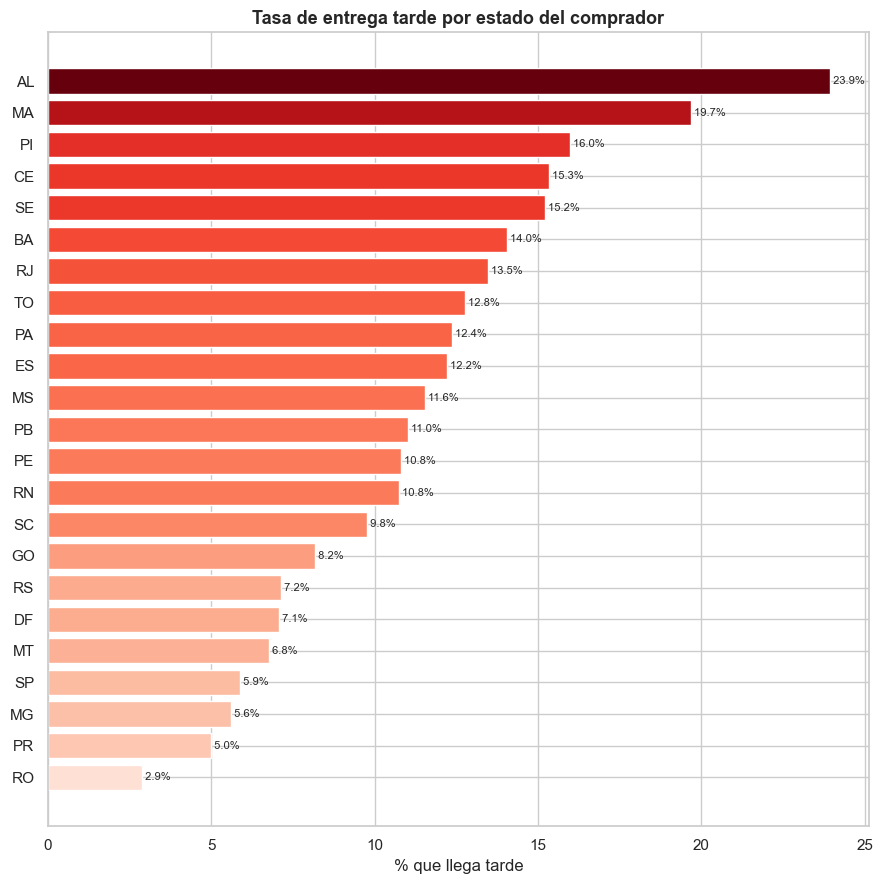

Reencuadre: P1 = 'Olist entrega tarde al Norte/Nordeste'. Mas accionable y vendible.


In [27]:
# Visual: barras por estado
fig, ax = plt.subplots(figsize=(9, 9))
ga_s = ga.sort_values("tarde_pct")
colors = plt.cm.Reds(ga_s["tarde_pct"]/ga_s["tarde_pct"].max())
ax.barh(ga_s.index, ga_s["tarde_pct"], color=colors)
ax.set_title("Tasa de entrega tarde por estado del comprador"); ax.set_xlabel("% que llega tarde")
for i, (st, row) in enumerate(ga_s.iterrows()):
    ax.text(row["tarde_pct"], i, f" {row['tarde_pct']:.1f}%", va="center", fontsize=8)
plt.tight_layout(); savefig("07_estado_barras"); plt.show()
print("Reencuadre: P1 = 'Olist entrega tarde al Norte/Nordeste'. Mas accionable y vendible.")


In [28]:
# === 7.2 Distancia real (haversine) comprador <-> vendedor ===
geo_clean = geo[(geo["geolocation_lat"].between(-34, 6)) & (geo["geolocation_lng"].between(-74, -34))]
cent = (geo_clean.groupby("geolocation_zip_code_prefix")
        .agg(lat=("geolocation_lat","mean"), lng=("geolocation_lng","mean")).reset_index())
so = (items.drop_duplicates("order_id")[["order_id","seller_id"]]
      .merge(sellers[["seller_id","seller_zip_code_prefix","seller_state"]], on="seller_id", how="left"))
dc = d.merge(so, on="order_id", how="inner")
dc = dc.merge(cent.rename(columns={"geolocation_zip_code_prefix":"customer_zip_code_prefix","lat":"c_lat","lng":"c_lng"}),
              on="customer_zip_code_prefix", how="left")
dc = dc.merge(cent.rename(columns={"geolocation_zip_code_prefix":"seller_zip_code_prefix","lat":"s_lat","lng":"s_lng"}),
              on="seller_zip_code_prefix", how="left")
sin_cob = dc[["c_lat","s_lat"]].isna().any(axis=1).sum()
dc = dc.dropna(subset=["c_lat","s_lat","c_lng","s_lng"]).copy()
dc["dist_km"] = haversine(dc["c_lat"], dc["c_lng"], dc["s_lat"], dc["s_lng"])
dc["mismo_estado"] = dc["customer_state"] == dc["seller_state"]
print(f"Ordenes con cobertura geo: {len(dc):,} (excluidas {sin_cob:,} sin centroide)")
print(f"Distancia km -> mediana {dc['dist_km'].median():.0f} | p90 {dc['dist_km'].quantile(.9):.0f}")
dc["tramo_dist"] = pd.qcut(dc["dist_km"], 5, labels=["Q1 cerca","Q2","Q3","Q4","Q5 lejos"], duplicates="drop")
td = dc.groupby("tramo_dist", observed=True).agg(dist_media=("dist_km", lambda x: round(x.median())),
        tarde_pct=("entrega_tarde", lambda x: round(x.mean()*100,2)))
print("\nTardanza por tramo de distancia:"); print(td.to_string())
print("\nMismo vs distinto estado (tasa de tardanza %):")
print((dc.groupby("mismo_estado")["entrega_tarde"].mean()*100).round(2).to_string())


Ordenes con cobertura geo: 95,991 (excluidas 479 sin centroide)
Distancia km -> mediana 434 | p90 1457

Tardanza por tramo de distancia:
            dist_media  tarde_pct
tramo_dist                       
Q1 cerca            34       6.50
Q2                 277       6.83
Q3                 434       7.59
Q4                 695       8.57
Q5 lejos          1457      11.01

Mismo vs distinto estado (tasa de tardanza %):
mismo_estado
False    9.26
True     6.05


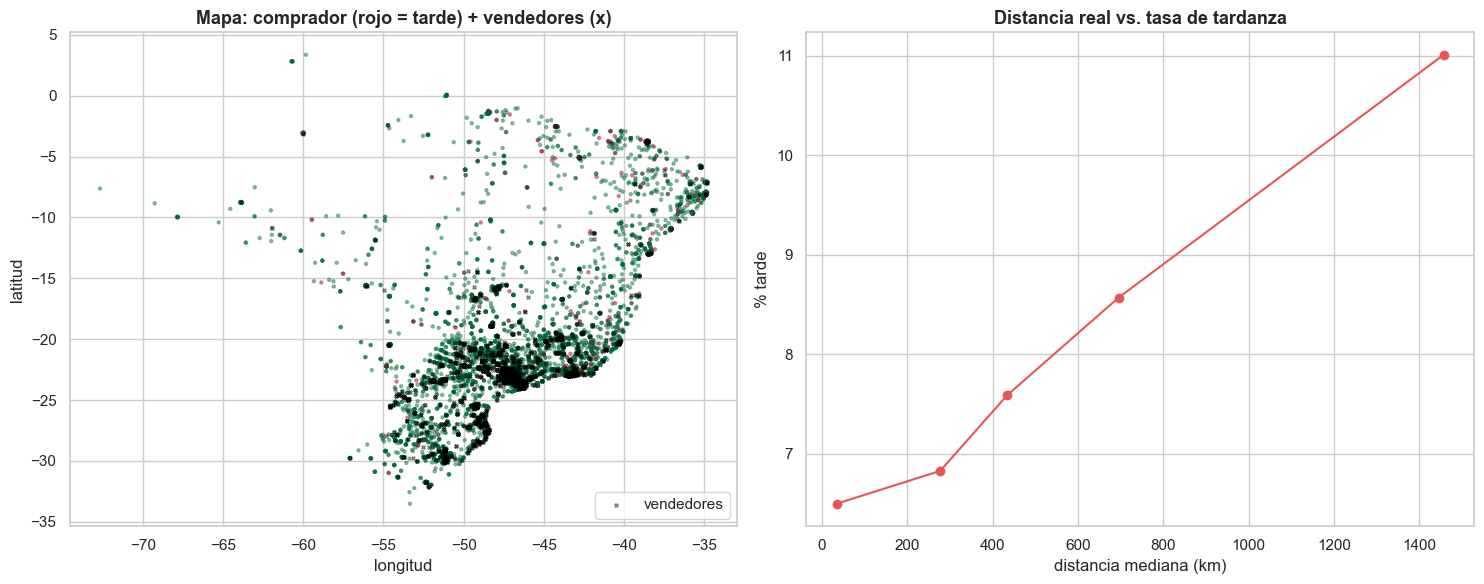

La tardanza sube con la distancia pero SUAVE: la promesa compensa parcialmente.


In [29]:
# Visual: "mapa" sin geopandas + distancia vs tardanza
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ms = dc.sample(min(15000, len(dc)), random_state=42)
ax[0].scatter(ms["c_lng"], ms["c_lat"], c=ms["entrega_tarde"].astype(int), cmap="RdYlGn_r", s=5, alpha=0.4)
sv = dc.dropna(subset=["s_lat","s_lng"]).drop_duplicates("seller_id")
ax[0].scatter(sv["s_lng"], sv["s_lat"], c="black", s=6, alpha=0.5, marker="x", label="vendedores")
ax[0].set_title("Mapa: comprador (rojo = tarde) + vendedores (x)")
ax[0].set_xlabel("longitud"); ax[0].set_ylabel("latitud"); ax[0].legend(loc="lower right")
ax[1].plot(td["dist_media"], td["tarde_pct"], marker="o", color=PALETA["tarde"])
ax[1].set_title("Distancia real vs. tasa de tardanza"); ax[1].set_xlabel("distancia mediana (km)"); ax[1].set_ylabel("% tarde")
plt.tight_layout(); savefig("07_mapa_distancia"); plt.show()
print("La tardanza sube con la distancia pero SUAVE: la promesa compensa parcialmente.")


In [30]:
# === 7.3 Donde se queda corta la promesa (la palanca, localizada) ===
col_estado = e.groupby("customer_state").agg(ordenes=("colchon","size"),
        colchon_mediano=("colchon","median"), tarde_pct=("entrega_tarde", lambda x: round(x.mean()*100,2)))
col_estado = col_estado[col_estado["ordenes"] >= 200].sort_values("colchon_mediano")
print("Estados con MENOS colchon (promesa ajustada -> mas riesgo de quedarse corta):")
print(col_estado.head(8).to_string())
print("\n... y con MAS colchon (promesa holgada -> se podria prometer mas rapido):")
print(col_estado.tail(8).to_string())


Estados con MENOS colchon (promesa ajustada -> mas riesgo de quedarse corta):
                ordenes  colchon_mediano  tarde_pct
customer_state                                     
AL                  397             10.0      23.93
MA                  717             10.0      19.67
SP                40494             10.0       5.89
ES                 1995             11.0      12.23
DF                 2080             12.0       7.07
CE                 1279             12.0      15.32
GO                 1957             12.0       8.18
BA                 3256             12.0      14.04

... y con MAS colchon (promesa holgada -> se podria prometer mas rapido):
                ordenes  colchon_mediano  tarde_pct
customer_state                                     
PR                 4923             13.0       5.00
RS                 5344             14.0       7.15
PE                 1593             14.0      10.80
PB                  517             14.0      11.03
MT             

### 7.4 Matriz de correlaciones entre features [t0]

*Colocada aquí (no en la Sección 6) porque necesita la distancia que se calcula en 7.2.* Consolida los features numéricos de las Secciones 6 y 7 para detectar **multicolinealidad** (variables que cargan la misma información) antes del modelado. **Solo features [t0]** (+ el target como referencia); incluir variables [POST] sería incoherente con el mapa de leakage.

In [31]:
# === 7.4 Matriz de correlaciones [t0] ===
# Tasa historica del vendedor: proxy de EDA (tasa global por vendedor). La version leak-free
# por ventana es FE; aqui solo queremos ver su correlacion con el resto.
seller_rate = v.groupby("seller_id")["entrega_tarde"].mean()
seller_de_orden = items.drop_duplicates("order_id").set_index("order_id")["seller_id"]

F = d[["order_id","entrega_tarde"]].copy()
F["dias_prometidos"]   = F["order_id"].map(e.set_index("order_id")["dias_prometidos"])
F = F.merge(dc[["order_id","dist_km","mismo_estado"]], on="order_id", how="left")
F = F.merge(f[["order_id","ratio_flete"]], on="order_id", how="left")
F = F.merge(p[["order_id","product_weight_g","volumen_cm3"]], on="order_id", how="left")
F["seller_hist_tarde"] = F["order_id"].map(seller_de_orden).map(seller_rate)
F["mismo_estado"]  = F["mismo_estado"].astype("float")
F["entrega_tarde"] = F["entrega_tarde"].astype(int)

num = ["entrega_tarde","dias_prometidos","dist_km","mismo_estado","ratio_flete",
       "product_weight_g","volumen_cm3","seller_hist_tarde"]
corr = F[num].corr(method="spearman")
comp = F[num].dropna()
print(f"Cobertura (filas con TODOS los features): {len(comp):,} de {len(F):,} ({len(comp)/len(F)*100:.1f}%)")
print(corr.round(2).to_string())


Cobertura (filas con TODOS los features): 95,962 de 96,470 (99.5%)
                   entrega_tarde  dias_prometidos  dist_km  mismo_estado  ratio_flete  product_weight_g  volumen_cm3  seller_hist_tarde
entrega_tarde               1.00            -0.05     0.06         -0.06         0.00              0.02         0.01               0.19
dias_prometidos            -0.05             1.00     0.62         -0.59         0.14              0.08         0.06              -0.04
dist_km                     0.06             0.62     1.00         -0.76         0.22              0.03         0.02              -0.03
mismo_estado               -0.06            -0.59    -0.76          1.00        -0.20             -0.02        -0.01               0.06
ratio_flete                 0.00             0.14     0.22         -0.20         1.00             -0.28        -0.19              -0.04
product_weight_g            0.02             0.08     0.03         -0.02        -0.28              1.00         0.77 

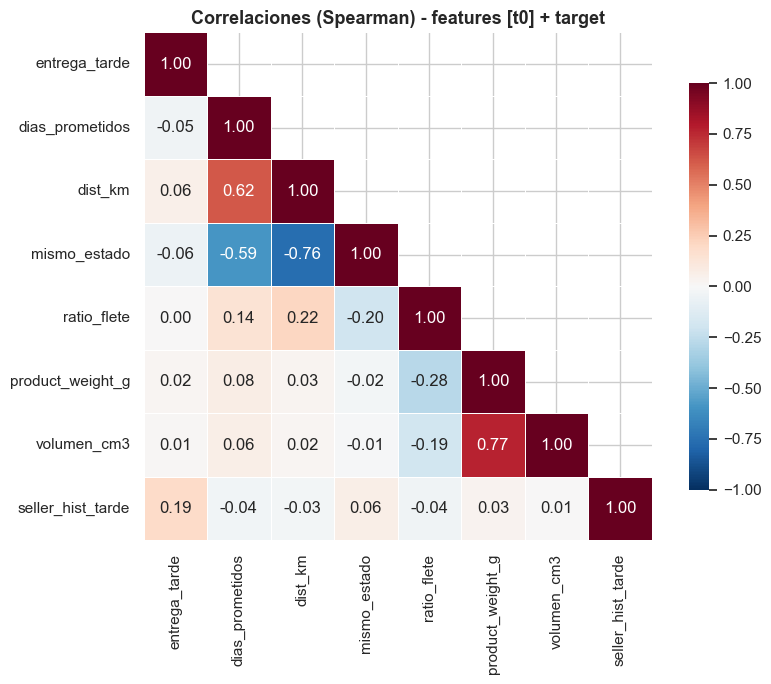

Multicolinealidad esperada: dist_km <-> mismo_estado y product_weight_g <-> volumen_cm3.
Ninguna feature [t0] correlaciona FUERTE con el target -> dolor multifactorial (la promesa
ya absorbe buena parte de la senal). Esto adelanta que el modelo necesitara varias features.


In [32]:
# Visual: heatmap de correlaciones (Spearman)
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink":0.8}, ax=ax)
ax.set_title("Correlaciones (Spearman) - features [t0] + target")
plt.tight_layout(); savefig("07_correlaciones"); plt.show()
print("Multicolinealidad esperada: dist_km <-> mismo_estado y product_weight_g <-> volumen_cm3.")
print("Ninguna feature [t0] correlaciona FUERTE con el target -> dolor multifactorial (la promesa")
print("ya absorbe buena parte de la senal). Esto adelanta que el modelo necesitara varias features.")


## 8. Mapa de leakage + cobertura + shortlist de features  *(handoff)*

Entrega del EDA hacia el *feature engineering*.

### Variables **[t0]** - candidatas a feature (legítimas)
| Variable / feature | Origen | Nota |
|---|---|---|
| `dias_prometidos` (estimada − compra) | orders | la promesa; ancla del problema |
| estado y zip del comprador | customers | base de la geografía |
| estado y zip del vendedor | sellers (vía items) | concentración en SP |
| `dist_km` (haversine) | geolocation | driver suave pero real |
| `mismo_estado` | derivada | correlaciona con distancia |
| `ratio_flete` | items | driver débil, pero [t0] |
| peso / volumen / categoría | products | logística del paquete |
| mes / día de compra | orders | estacionalidad |
| **tasa histórica de despacho/entrega tardía del vendedor** | derivada (ventana, ver 6.1-bis) | la señal de P3 entra aquí |
| `shipping_limit_date` | items | plazo de despacho, fijado al comprar |

### Variables **[POST]** - FUGA (prohibidas como feature)
| Variable | Por qué es fuga |
|---|---|
| `order_delivered_customer_date` | es el resultado (define el target) |
| `order_delivered_carrier_date` | solo se sabe cuando el vendedor ya despachó |
| `dias_reales` de tránsito | resultado |
| `review_score` / `insatisfecho` | ocurre DESPUÉS de la entrega |

> **Regla de oro:** la fecha de entrega real *etiqueta* el histórico (legítimo), nunca es *feature*. La tasa del vendedor se calcula **excluyendo la orden actual**.

In [33]:
# === 8. Cobertura de los features [t0] (cuantas ordenes los tendrian) ===
cobertura = {
    "dias_prometidos": F["dias_prometidos"].notna().mean(),
    "dist_km (geo)":   F["dist_km"].notna().mean(),
    "ratio_flete":     F["ratio_flete"].notna().mean(),
    "peso/volumen":    F["product_weight_g"].notna().mean(),
    "seller_hist":     F["seller_hist_tarde"].notna().mean(),
}
print("Cobertura por feature (% de ordenes con el dato disponible):")
for k, vv in cobertura.items():
    print(f"  {k:18}: {vv*100:5.1f}%")
completas = F[["dias_prometidos","dist_km","ratio_flete","product_weight_g","seller_hist_tarde"]].dropna()
print(f"\nOrdenes con TODOS los features [t0]: {len(completas):,} de {len(F):,} ({len(completas)/len(F)*100:.1f}%)")
print("\nLa feature mas limitante suele ser la geo (zips sin centroide). Estrategia de imputacion")
print("(a decidir en FE): geo faltante -> centroide del estado; vendedor sin historial -> tasa")
print("global; producto sin dimensiones -> mediana de su categoria.")


Cobertura por feature (% de ordenes con el dato disponible):
  dias_prometidos   : 100.0%
  dist_km (geo)     :  99.5%
  ratio_flete       : 100.0%
  peso/volumen      : 100.0%
  seller_hist       : 100.0%

Ordenes con TODOS los features [t0]: 95,962 de 96,470 (99.5%)

La feature mas limitante suele ser la geo (zips sin centroide). Estrategia de imputacion
(a decidir en FE): geo faltante -> centroide del estado; vendedor sin historial -> tasa
global; producto sin dimensiones -> mediana de su categoria.


## 9. Síntesis de hallazgos del EDA (P1)

1. **El target es sano.** `entrega_tarde` ~8.1% (minoría densa) - bueno para clasificar; sin el desbalance extremo que mató a otros candidatos.
2. **Tiene tamaño:** ~R$1.1M de GMV expuesto a la tardanza + GMV no realizado de las no-entregadas (2.98%); consistente con el embudo.
3. **La promesa lleva colchón** (mediana 12 días); el dolor vive en la cola que se queda corta. Palanca = **afinar la estimación**, no "entregar más rápido".
4. **El cliente reacciona a la promesa rota,** no a días absolutos.
5. **El vendedor mueve la tardanza** → feature histórica [t0]; la sensibilidad de ventana (6.1-bis) orienta el diseño en FE.
6. **Distancia importa (suave); flete casi nada.** Correlaciones moderadas y multifactoriales (7.4): el modelo necesitará varias features.
7. **P1 es regional:** Norte/Nordeste sufre ~4x más que SP. El reencuadre que hace P1 accionable y vendible.
8. **Disciplina de leakage establecida** + cobertura de features reportada: insumo directo del *feature engineering*.

---
### Pendiente para los siguientes chats (fuera del alcance de este EDA)
- *Feature engineering*: tasa histórica del vendedor con la ventana elegida (6.1-bis), sin fuga; encodings de estado/categoría; imputación de geo.
- Decisión target binario (`entrega_tarde`) vs continuo (`dias_vs_promesa`).
- Modelado con validación **temporal** (para no filtrar el futuro) y la disciplina anti-leakage en el split.
- *Nice-to-have* diferido: NLP del texto de reseñas (40.6% tiene comentario).
